In [1]:
import sys
import os
import numpy as np
import pandas as pd
import tqdm

In [2]:
import pyconll

In [3]:
viet_train = pyconll.load_from_file("lt2222-v26/vietnamese/UD_Vietnamese-VTB/vi_vtb-ud-train.conllu")

In [4]:
def create_instance(sentence, index, scope=2, include_current=False, feature_type="form", class_type="upos"):
    features = {}
    clazz = getattr(sentence[index], class_type)
    for i in range(-scope, scope+1):
        if not include_current and (i == 0):
            continue

        #print("at {} for index {} in a sentence of length {}".format(i, index, len(sentence)))
        if i+index < 0 or i+index+1 > len(sentence):
            features['NONE_{}'.format(i)] = 1
        else:
            features['{}_{}'.format(getattr(sentence[i+index], feature_type), i)] = 1
    
    return {'features':features, 'class':clazz}

In [5]:
def create_dataset(corpus, scope=2, include_current=False, feature_type="form", class_type="upos"):
    data = [[create_instance(i, j, scope, include_current, feature_type, class_type) for j in range(len(i))] for i in tqdm.tqdm(corpus)]
    feature_insts = []
    class_insts = []
    for sentence in data:
        for token in sentence:
            feature_insts.append(token['features'])
            class_insts.append(token['class'])
    return (pd.DataFrame(feature_insts).fillna(0), pd.Series(class_insts))
            

In [6]:
traindf, train_classes = create_dataset(viet_train)

100%|█████████████████████████████████████| 1400/1400 [00:00<00:00, 7087.45it/s]


In [7]:
viet_test = pyconll.load_from_file("lt2222-v26/vietnamese/UD_Vietnamese-VTB/vi_vtb-ud-test.conllu")

In [8]:
testdf, test_classes = create_dataset(viet_test)

100%|███████████████████████████████████████| 800/800 [00:00<00:00, 5610.81it/s]


In [10]:
testdf

,NONE_-2,NONE_-1,bắt chuyện_1,với_2,Thanh_-1,với_1,Hùng_2,Thanh_-2,bắt chuyện_-1,Hùng_1,...,thương mại_-2,câu lạc bộ_1,Cùng_-1,trốn_2,Cùng_-2,câu lạc bộ_-1,trốn_1,câu lạc bộ_-2,trốn_-1,trốn_-2
0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11687,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11690,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
traindf

,NONE_-2,NONE_-1,nhớ_1,lời_2,Tôi_-1,lời_1,anh_2,Tôi_-2,nhớ_-1,anh_1,...,đánh máy_2,đánh máy_1,đánh máy_-1,đánh máy_-2,trở lại_-2,Đòi_-1,Đòi_-2,đánh cắp_2,đánh cắp_1,đánh cắp_-1
0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20210,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20211,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
20212,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
nontrain_columns = [x for x in testdf.columns if x not in traindf.columns]

In [13]:
len(nontrain_columns)

4095

In [14]:
testdf_trainonly = testdf.drop(nontrain_columns, axis=1)

In [15]:
testdf_trainonly.columns

Index(['NONE_-2', 'NONE_-1', 'bắt chuyện_1', 'với_2', 'Thanh_-1', 'với_1',
       'Hùng_2', 'Thanh_-2', 'bắt chuyện_-1', 'Hùng_1',
       ...
       'thương mại_2', 'thương mại_1', 'thương mại_-1', 'thương mại_-2',
       'Cùng_-1', 'trốn_2', 'Cùng_-2', 'trốn_1', 'trốn_-1', 'trốn_-2'],
      dtype='object', length=5022)

In [16]:
len([x for x in testdf_trainonly.columns if x in traindf.columns])

5022

In [17]:
len([x for x in traindf.columns if x in testdf_trainonly.columns])

5022

In [18]:
nontest_columns = [x for x in traindf.columns if x not in testdf_trainonly.columns]

In [19]:
len(nontest_columns)

9117

In [20]:
5022 + 9117

14139

In [21]:
[x for x in nontest_columns if x in testdf.columns]

[]

In [22]:
testdf.columns

Index(['NONE_-2', 'NONE_-1', 'bắt chuyện_1', 'với_2', 'Thanh_-1', 'với_1',
       'Hùng_2', 'Thanh_-2', 'bắt chuyện_-1', 'Hùng_1',
       ...
       'thương mại_-2', 'câu lạc bộ_1', 'Cùng_-1', 'trốn_2', 'Cùng_-2',
       'câu lạc bộ_-1', 'trốn_1', 'câu lạc bộ_-2', 'trốn_-1', 'trốn_-2'],
      dtype='object', length=9117)

In [23]:
'NONE_-2' in nontest_columns

False

In [24]:
columns_matrix = np.zeros((len(testdf_trainonly), len(nontest_columns)))

In [25]:
columns_matrix.shape

(11692, 9117)

In [26]:
missing_df = pd.DataFrame(columns_matrix, index=testdf_trainonly.index, columns=nontest_columns)

In [27]:
missing_df

,chủ tịch_2,chủ tịch_1,Bùi Văn Luyến_2,chủ tịch_-1,Bùi Văn Luyến_1,chủ tịch_-2,Bùi Văn Luyến_-1,Bùi Văn Luyến_-2,Coi bộ_2,Coi bộ_1,...,đánh máy_2,đánh máy_1,đánh máy_-1,đánh máy_-2,trở lại_-2,Đòi_-1,Đòi_-2,đánh cắp_2,đánh cắp_1,đánh cắp_-1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11687,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11690,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
testdf_trainonly

,NONE_-2,NONE_-1,bắt chuyện_1,với_2,Thanh_-1,với_1,Hùng_2,Thanh_-2,bắt chuyện_-1,Hùng_1,...,thương mại_2,thương mại_1,thương mại_-1,thương mại_-2,Cùng_-1,trốn_2,Cùng_-2,trốn_1,trốn_-1,trốn_-2
0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11687,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11690,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
testdf_fixed = pd.concat([testdf_trainonly, missing_df], axis = 1)

In [30]:
testdf_fixed

,NONE_-2,NONE_-1,bắt chuyện_1,với_2,Thanh_-1,với_1,Hùng_2,Thanh_-2,bắt chuyện_-1,Hùng_1,...,đánh máy_2,đánh máy_1,đánh máy_-1,đánh máy_-2,trở lại_-2,Đòi_-1,Đòi_-2,đánh cắp_2,đánh cắp_1,đánh cắp_-1
0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11687,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11690,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
traindf

,NONE_-2,NONE_-1,nhớ_1,lời_2,Tôi_-1,lời_1,anh_2,Tôi_-2,nhớ_-1,anh_1,...,đánh máy_2,đánh máy_1,đánh máy_-1,đánh máy_-2,trở lại_-2,Đòi_-1,Đòi_-2,đánh cắp_2,đánh cắp_1,đánh cắp_-1
0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20210,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20211,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
20212,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
from sklearn.naive_bayes import MultinomialNB

In [33]:
mnb = MultinomialNB()

In [34]:
mnb.fit(traindf, train_classes)

MultinomialNB()

In [35]:
test_predictions = mnb.predict(testdf_fixed[traindf.columns])

In [36]:
from sklearn.metrics import accuracy_score

In [37]:
accuracy_score(test_classes, test_predictions)

0.4313205610673965

In [38]:
len(set(test_classes))

17

In [39]:
set(test_classes)

{'ADJ',
 'ADP',
 'ADV',
 'AUX',
 'CCONJ',
 'DET',
 'INTJ',
 'NOUN',
 'NUM',
 'PART',
 'PRON',
 'PROPN',
 'PUNCT',
 'SCONJ',
 'SYM',
 'VERB',
 'X'}

In [40]:
len([x for x in test_classes if x == "NOUN"])

3029

In [41]:
len(test_classes)

11692

In [42]:
3029/11692

0.2590660280533698

In [43]:
import matplotlib.pyplot as plt

(array([4624., 6512., 1481., 4028.,  501.,  728., 1682.,  300.,   70.,
         289.]),
 array([ 0. ,  1.6,  3.2,  4.8,  6.4,  8. ,  9.6, 11.2, 12.8, 14.4, 16. ]),
 <BarContainer object of 10 artists>)

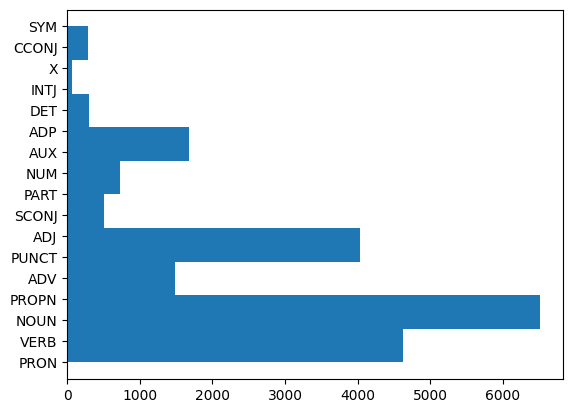

In [45]:
plt.hist(train_classes, orientation="horizontal")

(array([2694.,  789., 1703., 3560., 1020.,  106.,  759.,  161.,  651.,
         249.]),
 array([ 0. ,  1.6,  3.2,  4.8,  6.4,  8. ,  9.6, 11.2, 12.8, 14.4, 16. ]),
 <BarContainer object of 10 artists>)

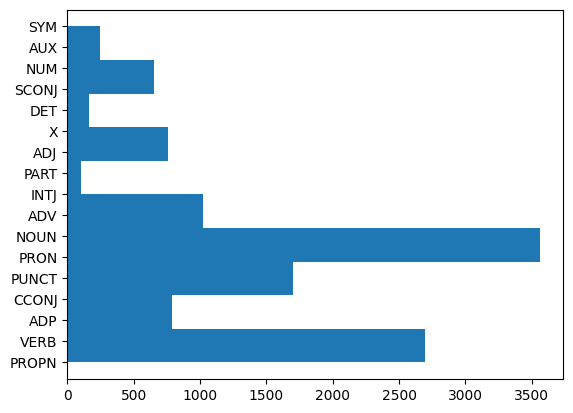

In [46]:
plt.hist(test_classes, orientation="horizontal")

(array([9.535e+03, 1.625e+03, 2.600e+02, 3.700e+01, 2.100e+01, 5.100e+01,
        1.110e+02, 4.800e+01, 1.000e+00, 3.000e+00]),
 array([ 0. ,  1.1,  2.2,  3.3,  4.4,  5.5,  6.6,  7.7,  8.8,  9.9, 11. ]),
 <BarContainer object of 10 artists>)

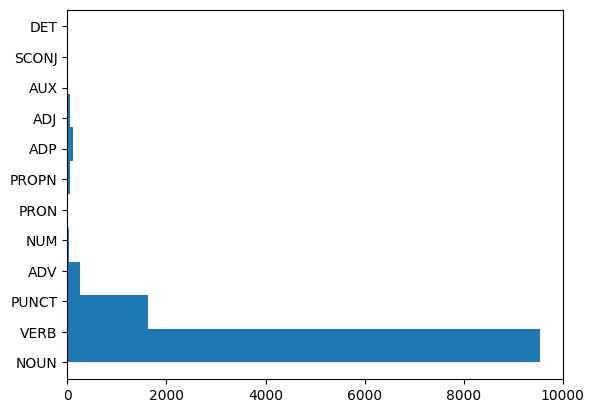

In [47]:
plt.hist(test_predictions, orientation="horizontal")

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [82]:
%matplotlib inline

In [83]:
cfm = confusion_matrix(test_classes, test_predictions)

<Figure size 640x480 with 0 Axes>

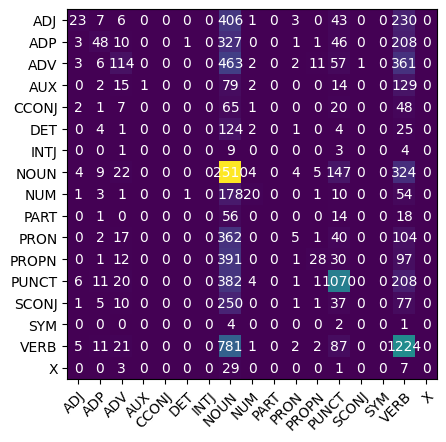

In [96]:
plt.clf()
figure, axes = plt.subplots()

labels = sorted(set(test_classes))

axes.set_xticks(range(len(labels)), labels=labels,
                rotation=45, ha="right", rotation_mode="anchor")
axes.set_yticks(range(len(labels)), labels=labels)


# Loop over data dimensions and create text annotations.
for i in range(len(labels)):
    for j in range(len(labels)):
        text = axes.text(j, i, cfm[i, j],
                         ha="center", va="center", color="w")
im = axes.imshow(cfm)

In [95]:
figure.tight_layout()
plt.show(im)

In [97]:
traindf, train_classes = create_dataset(viet_train, feature_type="upos")

100%|████████████████████████████████████| 1400/1400 [00:00<00:00, 12398.55it/s]


In [98]:
testdf, test_classes = create_dataset(viet_test, feature_type="upos")

100%|██████████████████████████████████████| 800/800 [00:00<00:00, 13422.47it/s]


In [99]:
traindf

,NONE_-2,NONE_-1,VERB_1,NOUN_2,PRON_-1,NOUN_1,PRON_-2,VERB_-1,VERB_-2,NOUN_-1,...,CCONJ_2,CCONJ_1,CCONJ_-1,CCONJ_-2,SYM_2,SYM_1,SYM_-1,SYM_-2,INTJ_2,INTJ_1
0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20210,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20211,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20212,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [102]:
testdf

,NONE_-2,NONE_-1,VERB_1,ADP_2,PROPN_-1,ADP_1,PROPN_2,PROPN_-2,VERB_-1,PROPN_1,...,NUM_-1,NUM_-2,AUX_2,AUX_1,AUX_-1,AUX_-2,SYM_2,SYM_1,SYM_-1,SYM_-2
0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11687,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11690,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [103]:
mnb2 = MultinomialNB()

In [104]:
mnb2.fit(traindf, train_classes)

MultinomialNB()

In [108]:
test_predictions = mnb2.predict(testdf[traindf.columns])

In [109]:
accuracy_score(test_classes, test_predictions)

0.3994184057475197

In [110]:
cfm = confusion_matrix(test_classes, test_predictions)

<Figure size 640x480 with 0 Axes>

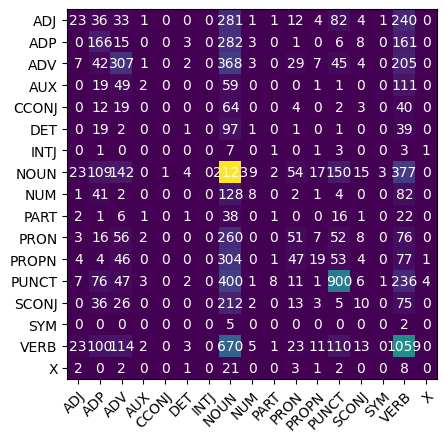

In [111]:
plt.clf()
figure, axes = plt.subplots()

labels = sorted(set(test_classes))

axes.set_xticks(range(len(labels)), labels=labels,
                rotation=45, ha="right", rotation_mode="anchor")
axes.set_yticks(range(len(labels)), labels=labels)


# Loop over data dimensions and create text annotations.
for i in range(len(labels)):
    for j in range(len(labels)):
        text = axes.text(j, i, cfm[i, j],
                         ha="center", va="center", color="w")
im = axes.imshow(cfm)

In [58]:
sums = traindf.sum(axis=1)

In [59]:
sums.min()

4.0

In [60]:
len(sums)

20215

In [61]:
sums2 = traindf.sum()

In [62]:
sums2

NONE_-2        1400.0
!_-1             33.0
nhớ_1             7.0
lời_2             6.0
!_-2             32.0
                ...  
Đòi_-1            1.0
Đòi_-2            1.0
đánh cắp_2        1.0
đánh cắp_1        1.0
đánh cắp_-1       1.0
Length: 14138, dtype: float64